In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"F:\Data_Analytics\Python\insurance_synthetic_data.xls")
df.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,charges
0,56,male,23.5,153,Yes,2,No,northeast,28309.76,24457.66
1,46,male,28.1,133,No,2,No,southwest,19454.47,17312.84
2,32,male,26.4,142,Yes,1,No,southeast,25998.33,21362.60
3,60,male,25.9,113,Yes,3,No,northeast,29782.52,26696.27
4,25,male,30.1,149,Yes,4,Yes,northwest,37532.64,35255.83


### Q1: What are the dimensions of the dataset (rows & columns)?

In [6]:
df.shape

(500, 10)

### Q2: What are the data types of each column?

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            500 non-null    int64  
 1   gender         500 non-null    object 
 2   bmi            500 non-null    float64
 3   bloodpressure  500 non-null    int64  
 4   diabetic       500 non-null    object 
 5   children       500 non-null    int64  
 6   smoker         500 non-null    object 
 7   region         500 non-null    object 
 8   claim          500 non-null    float64
 9   charges        500 non-null    float64
dtypes: float64(3), int64(3), object(4)
memory usage: 39.2+ KB


In [8]:
df.dtypes

age                int64
gender            object
bmi              float64
bloodpressure      int64
diabetic          object
children           int64
smoker            object
region            object
claim            float64
charges          float64
dtype: object

### Q3: Identify numerical and categorical columns.

In [10]:
numerical_cols = df.select_dtypes(include = ['number'])
numerical_cols

,age,bmi,bloodpressure,children,claim,charges
0,56,23.5,153,2,28309.76,24457.66
1,46,28.1,133,2,19454.47,17312.84
2,32,26.4,142,1,25998.33,21362.60
3,60,25.9,113,3,29782.52,26696.27
4,25,30.1,149,4,37532.64,35255.83
...,...,...,...,...,...,...
495,37,29.3,143,3,17240.05,20121.49
496,41,29.8,141,3,34912.47,30287.79
497,29,29.2,92,1,14038.61,14084.07
498,52,30.2,130,1,19721.48,21462.30


In [11]:
categorical_cols = df.select_dtypes(include = ['object'])
categorical_cols

,gender,diabetic,smoker,region
0,male,Yes,No,northeast
1,male,No,No,southwest
2,male,Yes,No,southeast
3,male,Yes,No,northeast
4,male,Yes,Yes,northwest
...,...,...,...,...
495,male,No,No,southeast
496,male,No,Yes,southeast
497,female,No,No,southeast
498,male,No,No,northeast


### Q4: Are there any missing values in the dataset?

In [16]:
df.isnull().sum()

age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
charges          0
dtype: int64

### Q5: How many unique values are present in each categorical column?

In [17]:
for i in categorical_cols:
    print(i, df[i].nunique())

gender 2
diabetic 2
smoker 2
region 4


In [18]:
categorical_cols.nunique()

gender      2
diabetic    2
smoker      2
region      4
dtype: int64

### Q6: What is the distribution of charges?

In [21]:
df = df.rename(columns = {'charges':'premium'})
df.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,premium
0,56,male,23.5,153,Yes,2,No,northeast,28309.76,24457.66
1,46,male,28.1,133,No,2,No,southwest,19454.47,17312.84
2,32,male,26.4,142,Yes,1,No,southeast,25998.33,21362.60
3,60,male,25.9,113,Yes,3,No,northeast,29782.52,26696.27
4,25,male,30.1,149,Yes,4,Yes,northwest,37532.64,35255.83


Text(0.5, 1.0, 'Distribution of Premium')

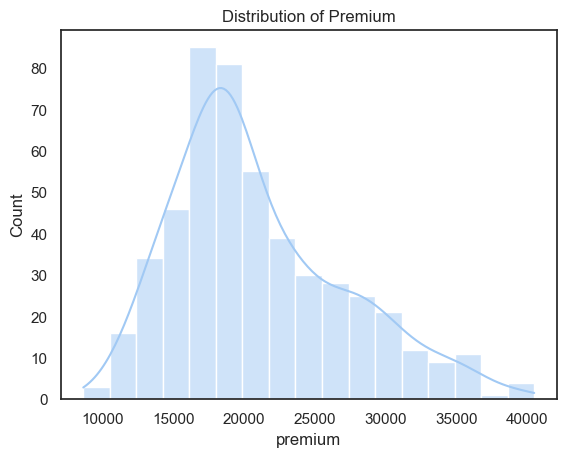

In [27]:
sns.set_theme(style = 'white', palette = 'pastel')
sns.histplot(x = 'premium', data = df, kde = True)
plt.title('Distribution of Premium')

### Q7: Is the distribution of charges skewed? If yes, in which direction?

Yes, The distribution of premium is **Right Skewed**.

### Q8: What are the summary statistics of charges?

In [36]:
df['premium'].describe()

count      500.000000
mean     20978.795180
std       6078.386111
min       8636.040000
25%      16750.982500
50%      19453.720000
75%      24394.202500
max      40510.960000
Name: premium, dtype: float64

### Q9: Are there any outliers in charges?

<Axes: xlabel='premium'>

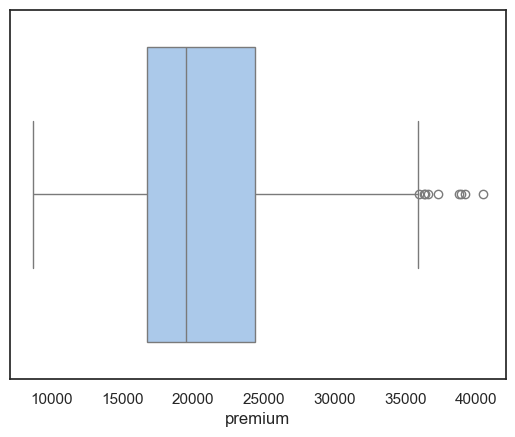

In [37]:
sns.boxplot(x = 'premium', data = df)

### Q10: What is the distribution of age?

Text(0.5, 1.0, 'Distribution of Age')

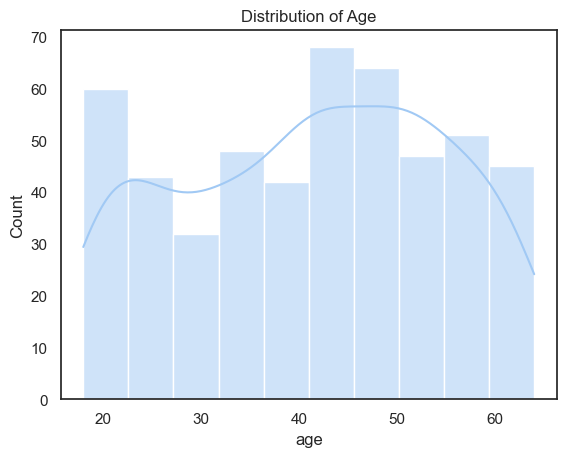

In [41]:
sns.set_theme(style = 'white', palette = 'pastel')
sns.histplot(x = 'age', data = df, kde = True)
#sns.histplot(df['age'], kde = True)
plt.title('Distribution of Age')

### Q11: What is the distribution of BMI?

Text(0.5, 1.0, 'Distribution of BMI')

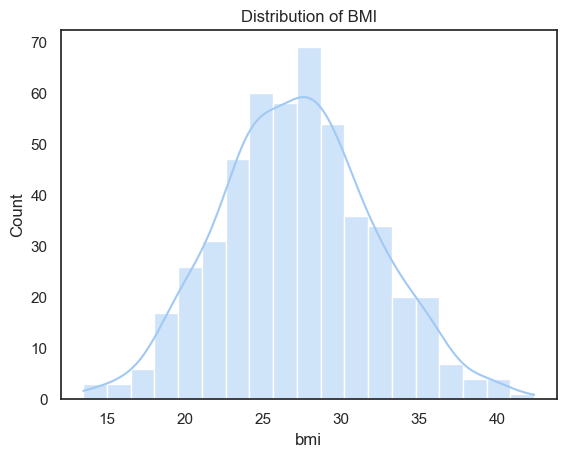

In [43]:
sns.histplot(df['bmi'], kde = True)
plt.title('Distribution of BMI')

### Q12: What is the distribution of number of children?

Text(0.5, 1.0, 'Distribution of Children')

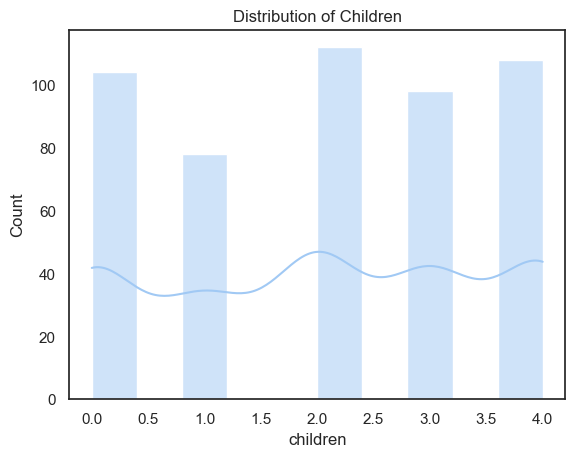

In [46]:
sns.histplot(x = 'children', data = df, kde = True)
plt.title('Distribution of Children')

### Q13: What is the gender distribution?

Text(0.5, 1.0, 'Gender Distribution')

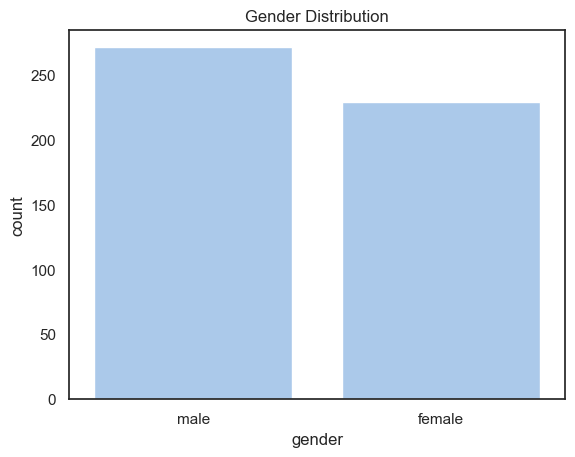

In [48]:
sns.countplot(x = 'gender', data=df)
plt.title('Gender Distribution')

### Q14: What is the smoker distribution?

Text(0.5, 1.0, 'Smoker Distribution')

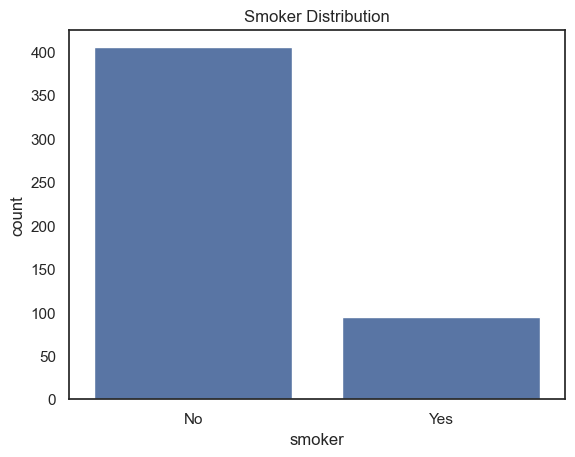

In [62]:
sns.set_theme(style = 'white', palette = 'deep')
sns.countplot(x = 'smoker', data=df)
plt.title('Smoker Distribution')

### Q15: What is the region distribution?

Text(0.5, 1.0, 'Region Distribution')

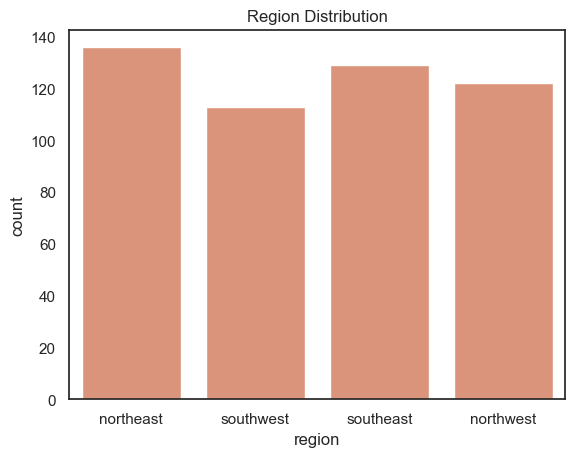

In [63]:
sns.set_theme(style = 'white', palette = 'flare')
sns.countplot(x = 'region', data=df)
plt.title('Region Distribution')

### Q16: Does smoking affect medical premium?

Text(0.5, 1.0, 'Smoker-Premium Relationship')

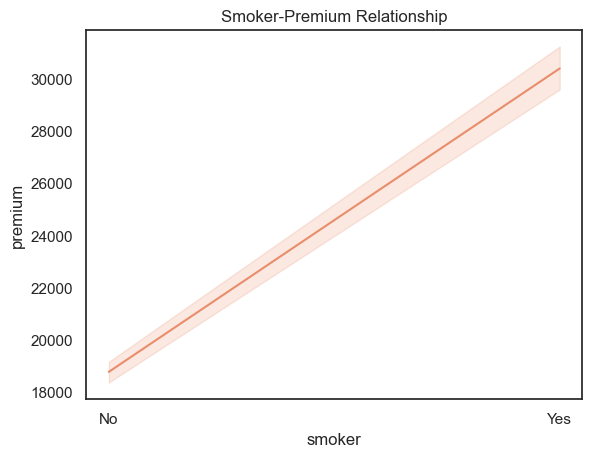

In [66]:
sns.lineplot(x = 'smoker', y = 'premium', data = df)
plt.title('Smoker-Premium Relationship')

Text(0.5, 1.0, 'Smoker-Premium Relationship')

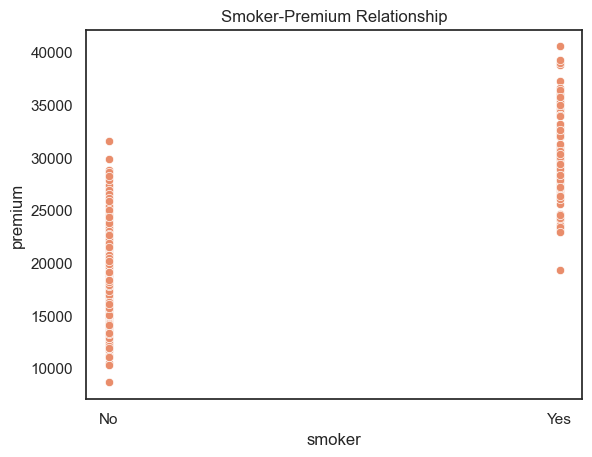

In [67]:
sns.scatterplot(x = 'smoker', y = 'premium', data = df)
plt.title('Smoker-Premium Relationship')

### Q17: What is the relationship between BMI and charges?

Text(0.5, 1.0, 'BMI-Premium Relationship')

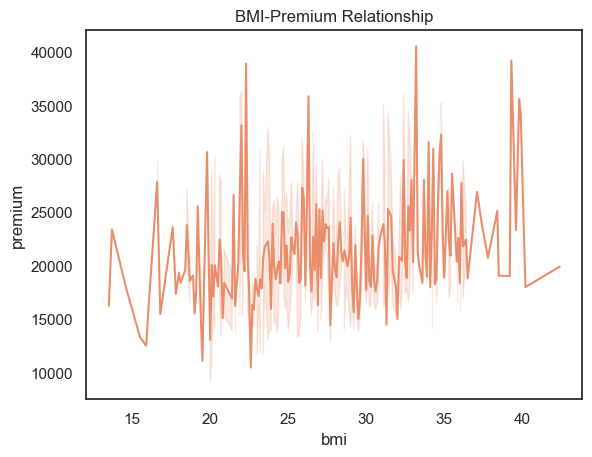

In [68]:
sns.lineplot(x = 'bmi', y = 'premium', data = df)
plt.title('BMI-Premium Relationship')

Text(0.5, 1.0, 'BMI-Premium Relationship')

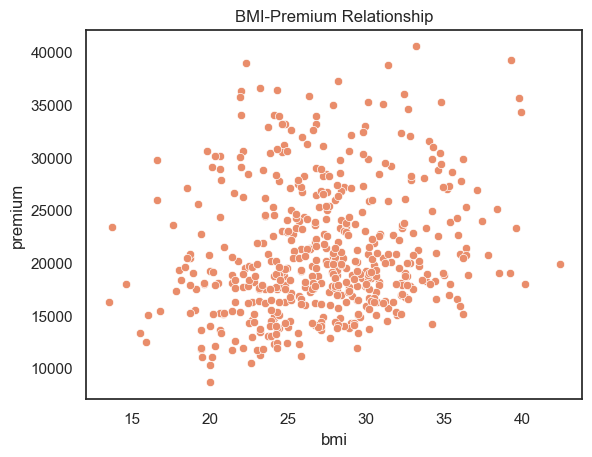

In [69]:
sns.scatterplot(x = 'bmi', y = 'premium', data = df)
plt.title('BMI-Premium Relationship')

**Insight** : *Most of the people paying premium lie in the bmi range of 27 to 32 and they pay premium between 12000 to 22000.*

### Q18: How does smoking influence the BMI vs charges relationship?

<Axes: xlabel='bmi', ylabel='premium'>

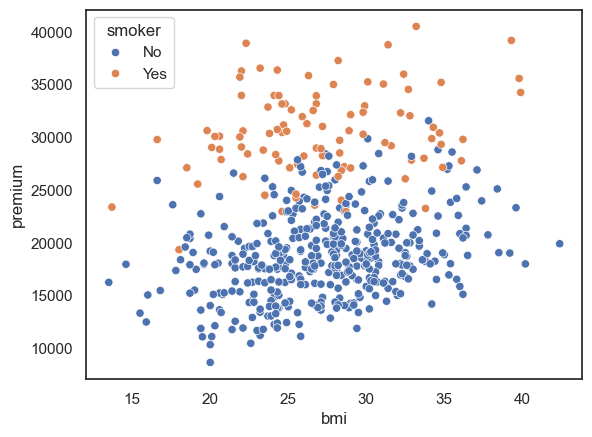

In [81]:
sns.set_theme(style = 'white', palette = 'deep')
sns.scatterplot(x = 'bmi', y = 'premium', data = df, hue = 'smoker')

### Q19: What is the relationship between age and charges?

Text(0.5, 1.0, 'Age vs Premium')

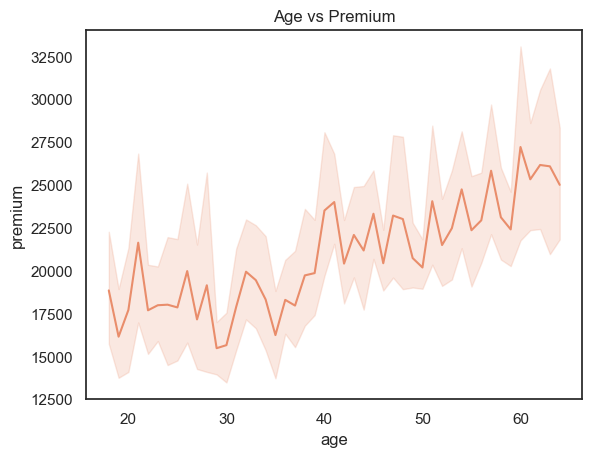

In [71]:
sns.lineplot(x = 'age', y = 'premium', data = df)
plt.title('Age vs Premium')

**Insight** : *The premium is increasing with the age.*

Text(0.5, 1.0, 'Age vs Premium')

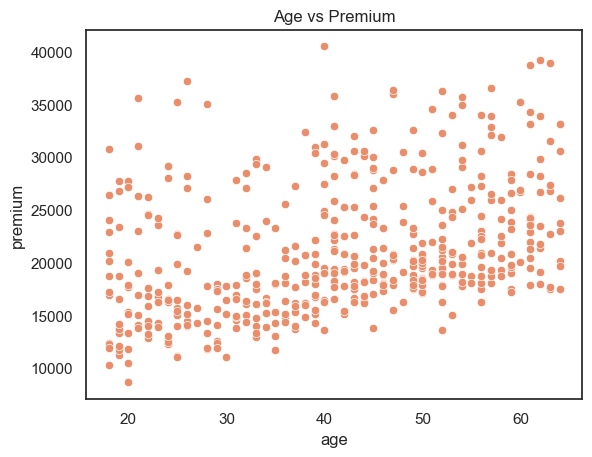

In [72]:
sns.scatterplot(x = 'age', y = 'premium', data = df)
plt.title('Age vs Premium')

### Q20: Do males and females differ in charges?

Text(0.5, 1.0, 'Gender vs Premium')

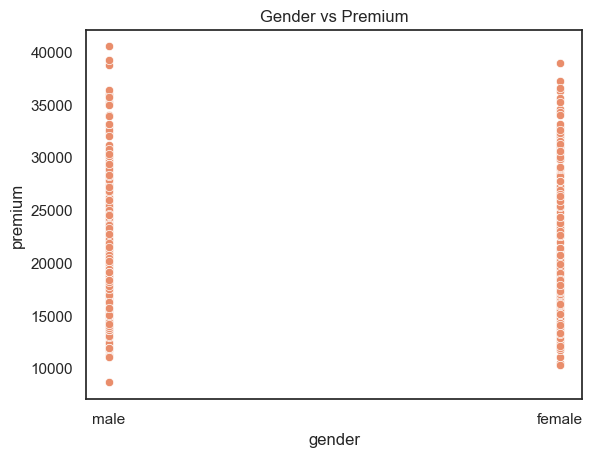

In [78]:
sns.scatterplot(x = 'gender', y = 'premium', data = df)
plt.title('Gender vs Premium')

**Insight** : *The overall premium is constant among male and female.*

### Q21: Does the number of children affect charges?

Text(0.5, 1.0, 'Children vs Premium')

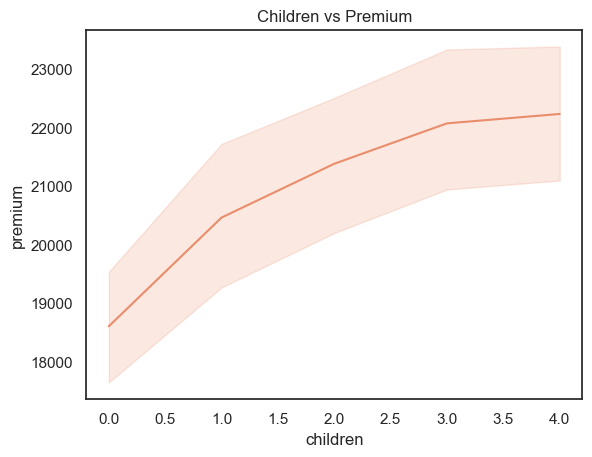

In [76]:
sns.lineplot(x = 'children', y = 'premium', data = df)
plt.title('Children vs Premium')

### Q22: Does region affect charges?

Text(0.5, 1.0, 'Region vs Premium')

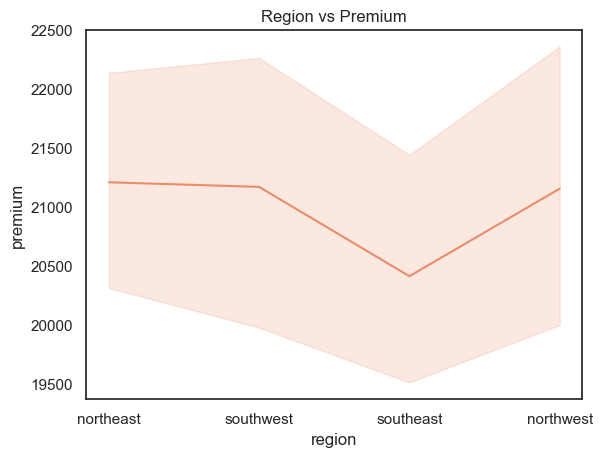

In [77]:
sns.lineplot(x = 'region', y = 'premium', data = df)
plt.title('Region vs Premium')

Text(0.5, 1.0, 'Region vs Premium')

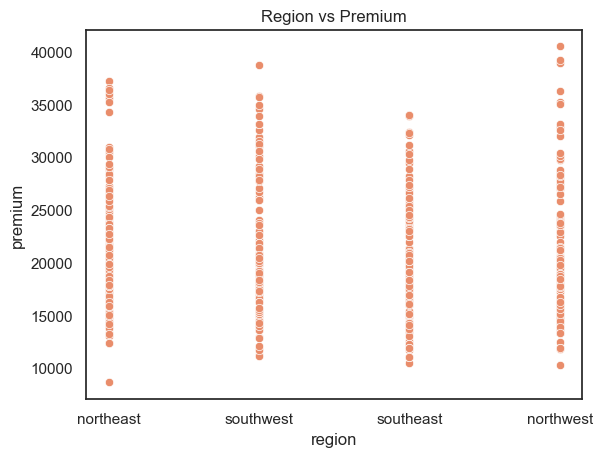

In [79]:
sns.scatterplot(x = 'region', y = 'premium', data = df)
plt.title('Region vs Premium')

### Q23: What are the pairwise relationships between variables?

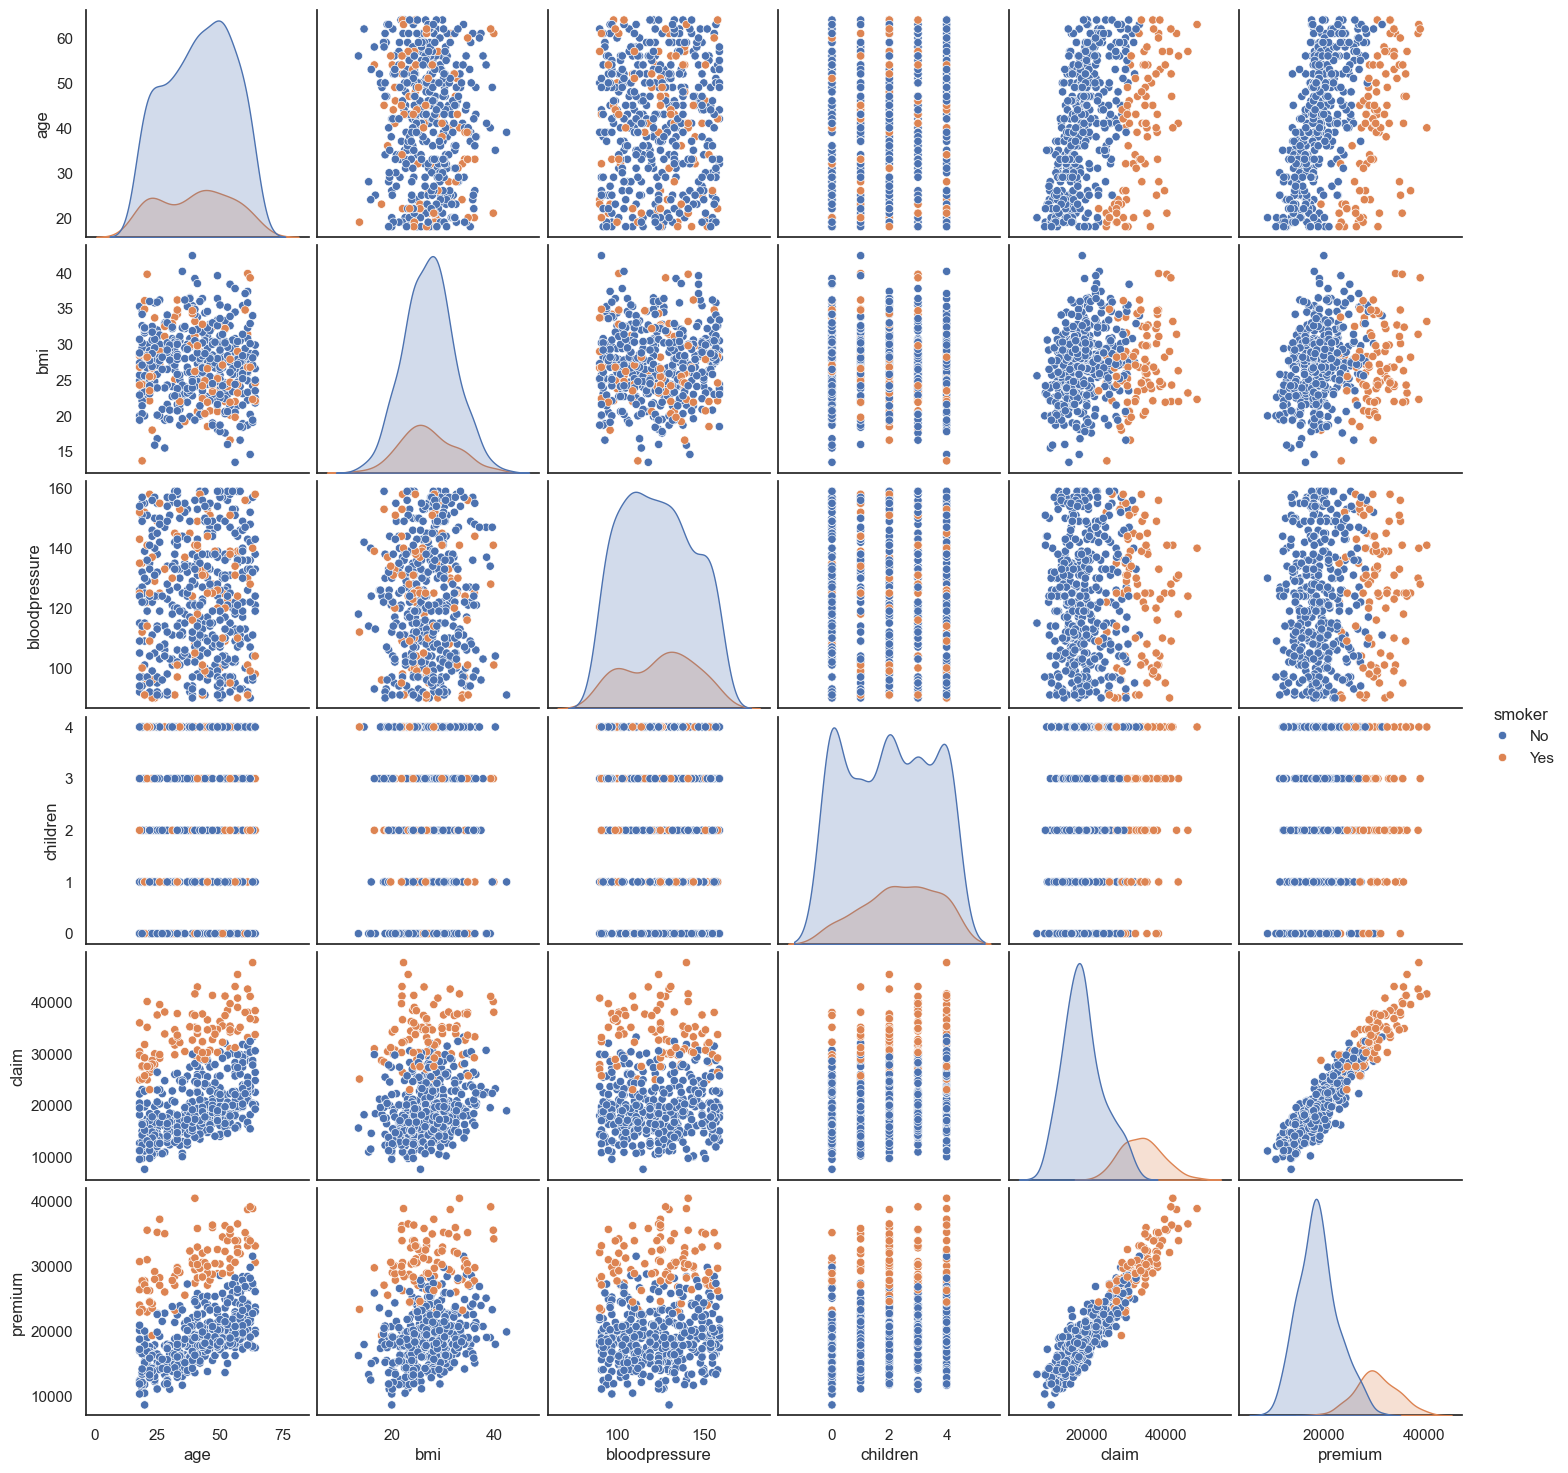

In [85]:
sns.pairplot(df, hue = 'smoker')

In [83]:
correlation = numerical_cols.corr()
correlation

,age,bmi,bloodpressure,children,claim,charges
age,1.000000,-0.068394,-0.008912,0.107828,0.332181,0.383241
bmi,-0.068394,1.000000,0.027774,-0.009208,0.156835,0.182035
bloodpressure,-0.008912,0.027774,1.000000,-0.044803,0.025294,0.079201
children,0.107828,-0.009208,-0.044803,1.000000,0.213224,0.210420
claim,0.332181,0.156835,0.025294,0.213224,1.000000,0.937747
charges,0.383241,0.182035,0.079201,0.210420,0.937747,1.000000


**Heatmap > Correlation between the columns**

<Axes: >

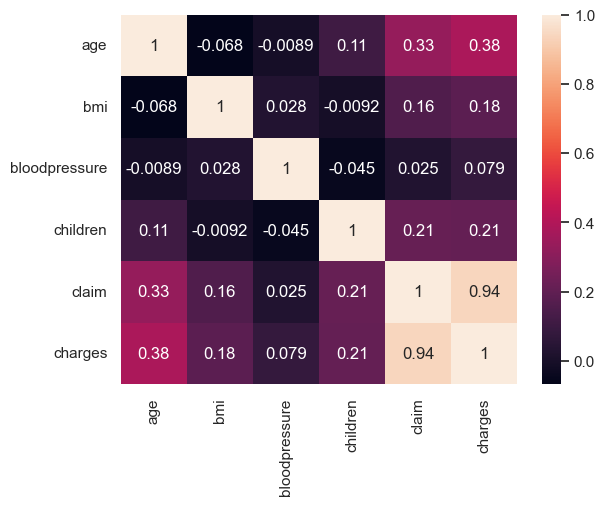

In [84]:
sns.heatmap(correlation, annot = True)

### Q24: What does the correlation heatmap reveal?

***There is a strong correlation between claim and premium***

### Q25: Which feature is most correlated with charges?

In [90]:
corr = correlation['charges'].sort_values(ascending = False).reset_index()
corr

,index,charges
0,charges,1.000000
1,claim,0.937747
2,age,0.383241
3,children,0.210420
4,bmi,0.182035
5,bloodpressure,0.079201


In [91]:
corr.iloc[1]

index         claim
charges    0.937747
Name: 1, dtype: object

### Q26: How does age vs charges differ by smoking status?

Text(0.5, 1.0, 'Age vs Premium')

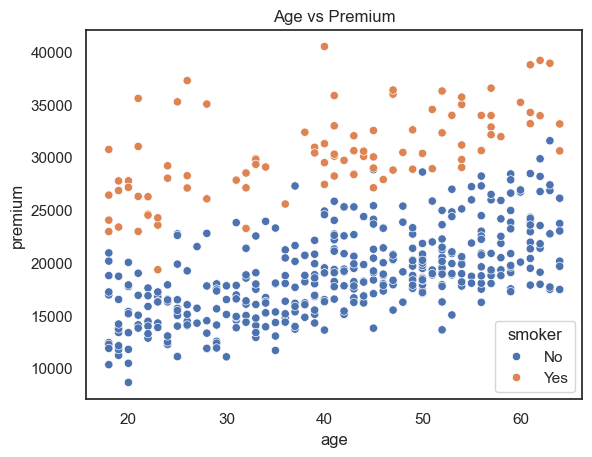

In [97]:
sns.scatterplot(x = 'age', y = 'premium', data = df, hue = 'smoker')
plt.title('Age vs Premium')

### Q27: What is the average charge for smokers vs non-smokers?

In [95]:
df.groupby('smoker')['premium'].mean()

smoker
No     18769.167802
Yes    30398.785579
Name: premium, dtype: float64

### Q28: What is the average charge by region?

In [100]:
df.groupby('region')['premium'].mean().reset_index()        # reset_index() : Series to DataFrame

,region,premium
0,northeast,21206.621838
1,northwest,21152.372049
2,southeast,20409.168605
3,southwest,21167.476814


### Q29: What is the average charge by gender?

In [101]:
df.groupby('gender')['premium'].mean()

gender
female    20933.338559
male      21017.206863
Name: premium, dtype: float64

### Q30: What is the average charge by number of children?

In [103]:
df.groupby('children')['premium'].mean().reset_index()

,children,premium
0,0,18599.655288
1,1,20460.554615
2,2,21381.432321
3,3,22072.933980
4,4,22233.724352
